
# 충청도 분석

Step 1. Business Understanding
- 문제 정의: 
    - 날씨가 전력 사용량에 영향을 미칠까?
    - 어떤 기상요인이 가장 영향이 클까?
    - 계약종별 차이는 있을까?
- 성공 기준: 
    - 상관관계 계산
    - 그래프로 시각화
    - 패턴과 인사이트 도출

Step 2. Data Understanding
- 사용 데이터: 기온/기상 데이터(weather), 전력사용량 데이터(elect)
- 주요변수: 평균기온, 습도, 기압, 계약종별, 사용량

Step 3. Data Preparation - Numpy/Pandas 활용
- 필터링: 시도컬럼에서 충청남도/충청북도만 추출
- 구조 변경: 가로로 나열된 월별 전력량을 세로로 변환
- 결측치&이상치 처리: 비어있는 값 제거 및 IQR 방식을 이용한 이상치 제거

Step 4. 모델링 
- 계약종별 상관관계 분석
- 기상 요인과 사용량 간의 시각화 탐색

Step 5. Evaluation & Deployment
- 인사이트 도출 및 결과물 정리 

In [379]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [380]:
# 한글폰트 설정
import matplotlib.font_manager as fm
import matplotlib

font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)

In [381]:
# 1. 데이터 로드 / 데이터 수집
weather = pd.read_csv('./data/201511_202511_weather.csv', encoding='cp949')
power = pd.read_csv('./data/elect_2015_2024.csv', encoding='cp949')
power = power.drop(columns=[null for null in power.columns if 'Unnamed' in null])

In [382]:
# 2. 데이터 확인
print(weather.shape)
print(power.shape)

(11554, 29)
(20203, 16)


In [383]:
# 데이터 확인
print(weather.columns)
print(power.columns)

Index(['지점', '지점명', '일시', '평균기온(°C)', '평균최고기온(°C)', '평균최저기온(°C)', '최고기온(°C)',
       '최저기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '일최다강수량(mm)', '소형총증발량(mm)', '대형총증발량(mm)',
       '평균풍속(m/s)', '최대풍속(m/s)', '평균운량(1/10)', '평균중하층운량(1/10)', '일조율(%)',
       '합계 일사량(MJ/m2)', '최심적설(cm)', '최심신적설(cm)', '평균 최저초상온도(°C)', '평균지면온도(°C)',
       '0.5m평균지중온도(°C)', '1.5m평균지중온도(°C)', '3.0m평균지중온도(°C)'],
      dtype='str')
Index(['연도', '시도', '시군구', '계약종별', '1월', '2월', '3월', '4월', '5월', '6월', '7월',
       '8월', '9월', '10월', '11월', '12월'],
      dtype='str')


In [384]:
# 데이터 확인
print(weather.head())
print(power.head())

   지점 지점명       일시  평균기온(°C)  평균최고기온(°C)  평균최저기온(°C)  최고기온(°C)  최저기온(°C)  \
0  90  속초  2015-11       8.4        11.5         5.5      21.7      -3.2   
1  90  속초  2015-12       3.0         6.8        -1.0      10.9      -7.2   
2  90  속초  2016-01      -1.2         2.7        -5.3      11.5     -16.4   
3  90  속초  2016-02       0.8         4.3        -3.0      10.3      -9.4   
4  90  속초  2016-03       7.0        11.4         2.4      21.5      -7.6   

   평균현지기압(hPa)  평균해면기압(hPa)  ...  평균중하층운량(1/10)  일조율(%)  합계 일사량(MJ/m2)  \
0       1021.5       1023.8  ...            NaN   32.40            NaN   
1       1021.1       1023.4  ...            NaN   55.65            NaN   
2       1019.7       1022.0  ...            NaN   69.39            NaN   
3       1019.7       1022.0  ...            NaN   63.23            NaN   
4       1017.9       1020.2  ...            NaN   56.44            NaN   

   최심적설(cm)  최심신적설(cm)  평균 최저초상온도(°C)  평균지면온도(°C)  0.5m평균지중온도(°C)  \
0       NaN        NaN       

In [385]:
# 데이터 확인
display(weather.describe())
display(power.describe())



,지점,평균기온(°C),평균최고기온(°C),평균최저기온(°C),최고기온(°C),최저기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),...,평균중하층운량(1/10),일조율(%),합계 일사량(MJ/m2),최심적설(cm),최심신적설(cm),평균 최저초상온도(°C),평균지면온도(°C),0.5m평균지중온도(°C),1.5m평균지중온도(°C),3.0m평균지중온도(°C)
count,11554.000000,11546.000000,11548.000000,11548.000000,11554.000000,11554.000000,11547.000000,11546.000000,11540.000000,11541.000000,...,8927.000000,11550.000000,5816.000000,599.000000,581.000000,11530.000000,11528.000000,1612.000000,1613.000000,1611.000000
mean,197.461312,13.522397,18.926576,8.840708,25.409140,2.704916,1004.088768,1016.480573,13.089636,69.871848,...,3.004996,51.791370,430.554068,7.264775,5.329604,6.375690,15.669891,15.809057,16.170428,16.415829
std,64.303040,9.223469,8.965651,9.791364,7.869836,10.902651,15.899714,6.700821,8.312120,10.882759,...,1.084355,12.040852,145.796089,13.886906,8.199692,10.630865,10.420130,8.332478,5.824566,3.697633
min,90.000000,-8.500000,-3.200000,-13.500000,3.500000,-25.200000,920.500000,1003.800000,2.100000,32.000000,...,0.000000,0.400000,0.000000,0.000000,0.000000,-20.900000,-6.200000,-0.200000,4.700000,8.300000
25%,136.000000,5.800000,11.200000,0.500000,19.300000,-5.800000,998.900000,1009.500000,5.900000,62.000000,...,2.200000,44.090000,308.657500,1.300000,1.200000,-2.800000,6.400000,8.300000,11.200000,13.500000
50%,202.000000,14.000000,20.100000,8.800000,26.900000,1.800000,1006.500000,1017.600000,10.700000,71.000000,...,2.900000,53.060000,428.285000,3.500000,3.200000,5.900000,16.300000,16.350000,16.400000,16.300000
75%,258.000000,21.900000,26.800000,17.800000,32.000000,12.300000,1014.500000,1022.800000,19.900000,78.000000,...,3.700000,60.667500,550.160000,7.000000,6.100000,16.100000,25.300000,23.425000,21.500000,19.600000
max,296.000000,29.900000,35.300000,27.500000,41.000000,25.200000,1026.500000,1028.400000,34.800000,99.000000,...,7.700000,104.490000,796.120000,162.800000,79.000000,27.500000,36.600000,32.300000,28.500000,26.100000


,연도,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
count,20203.000000,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04,2.020300e+04
mean,2018.995496,5.165850e+07,4.889807e+07,4.688303e+07,4.513766e+07,4.331040e+07,4.433324e+07,4.756985e+07,5.102155e+07,4.776498e+07,4.374591e+07,4.489367e+07,4.896661e+07
std,3.163738,1.387429e+08,1.287797e+08,1.319922e+08,1.279859e+08,1.276503e+08,1.277085e+08,1.365916e+08,1.408460e+08,1.337223e+08,1.288354e+08,1.263576e+08,1.355782e+08
min,2014.000000,-5.604902e+08,-1.014152e+08,0.000000e+00,0.000000e+00,-3.477031e+06,0.000000e+00,-5.603911e+08,0.000000e+00,-3.138182e+06,0.000000e+00,-9.153950e+05,-7.684100e+04
25%,2016.000000,2.214734e+06,2.106490e+06,1.845140e+06,1.674194e+06,1.340800e+06,1.220576e+06,1.153958e+06,1.140488e+06,1.150066e+06,1.187574e+06,1.553950e+06,1.963396e+06
50%,2019.000000,8.759378e+06,8.513091e+06,7.276150e+06,6.621374e+06,5.603150e+06,5.554711e+06,5.837623e+06,6.761813e+06,6.373496e+06,5.540825e+06,6.724500e+06,7.749466e+06
75%,2022.000000,3.983818e+07,3.900912e+07,3.423700e+07,3.292304e+07,3.067915e+07,3.222789e+07,3.527910e+07,4.115242e+07,3.731761e+07,3.165906e+07,3.305400e+07,3.631119e+07
max,2024.000000,1.927074e+09,1.798099e+09,1.772527e+09,1.712271e+09,1.723661e+09,1.757750e+09,1.943027e+09,2.171722e+09,1.962578e+09,1.980761e+09,1.696594e+09,1.837089e+09


In [386]:
# 3. Data Preparation - 전력량 데이터 - 충청지역 추출
chung_region = ['충청남도', '충청북도', '대전광역시', '세종특별자치시']
power_cc = power[power['시도'].isin(chung_region)].copy()

In [387]:
# 기상 데이터 - 충청지역 추출

chung_cities = ['서산', '청주', '대전', '제천', '보은', '천안', '보령', '부여', '금산']
weather_cc = weather[weather['지점명'].isin(chung_cities)].copy()

In [388]:
# 내가 필터링한 데이터가 잘 추출되었는지 확인/검증
print('전력 데이터 포함 지역:', power_cc['시도'].unique())
print("전력 데이터 시군구:", power_cc['시군구'].unique())
print('기상 데이터 포함 지점:', weather_cc['지점명'].unique())

전력 데이터 포함 지역: <StringArray>
['대전광역시', '충청북도', '충청남도', '세종특별자치시']
Length: 4, dtype: str
전력 데이터 시군구: <StringArray>
[ '동구',  '중구',  '서구', '대덕구', '유성구', '충주시', '제천시', '보은군', '옥천군', '영동군', '진천군',
 '괴산군', '음성군', '단양군', '청주시', '증평군', '아산시', '보령시', '공주시', '서산시', '천안시', '금산군',
 '연기군', '계룡시', '논산시', '부여군', '서천군', '청양군', '홍성군', '예산군', '당진시', '태안군', '세종시',
 '청원군']
Length: 34, dtype: str
기상 데이터 포함 지점: <StringArray>
['서산', '청주', '대전', '제천', '보은', '천안', '보령', '부여', '금산']
Length: 9, dtype: str


In [389]:
# 구조변경 - 전력 데이터: 1월~12월 컬럼을 행으로 변환 (월별 전력량 세로로 변환)
power_list = []

for idx, row in power_cc.iterrows():
    for month in range(1, 13):
        month_col = f'{month}월'
        if month_col in row.index and pd.notna(row[month_col]):
            period_val = pd.Period(year=int(row['연도']), month=month, freq='M')

            power_list.append({
                '년월': period_val,
                '계약종별': row['계약종별'],
                '전력사용량': row[month_col]
            })

power_long = pd.DataFrame(power_list)

# 계약종별 합계 계산
power_monthly = power_long.groupby(['년월', '계약종별'])['전력사용량'].sum().reset_index()

print(power_monthly.head())

        년월 계약종별       전력사용량
0  2014-01  가로등    37555728
1  2014-01  교육용   119241882
2  2014-01  농사용   235735842
3  2014-01  산업용  4732703948
4  2014-01  심 야   570218026


In [390]:
# 데이터 정제 (년/월 컬럼 생성) - 기상데이터: 일단위, 전력데이터: 월단위이므로 분석단위 맞추기
weather_cc['일시'] = pd.to_datetime(weather_cc['일시'])
weather_cc['년'] = weather_cc['일시'].dt.year
weather_cc['월'] = weather_cc['일시'].dt.month
weather_cc['년월'] = weather_cc['일시'].dt.to_period('M')
print(weather_cc[['일시', '년', '월', '년월']].head())

             일시     년   월       년월
2167 2015-11-01  2015  11  2015-11
2168 2015-12-01  2015  12  2015-12
2169 2016-01-01  2016   1  2016-01
2170 2016-02-01  2016   2  2016-02
2171 2016-03-01  2016   3  2016-03


In [391]:
# 데이터 정리
# 충청도 전체 월별 평균 계산

weather_monthly = weather_cc.groupby(['년월']).agg({
    '평균기온(°C)': 'mean',           # 평균 기온
    '평균현지기압(hPa)': 'mean',       # 평균 기압
    '평균상대습도(%)': 'mean',         # 평균 습도
    '평균풍속(m/s)': 'mean',          # 평균 풍속
    '일조율(%)': 'mean',              # 일조율
    '월합강수량(00~24h만)(mm)': 'mean' # 강수량
}).reset_index()


print(f"월별 기상 데이터: {weather_monthly.shape[0]}개월")
print(weather_monthly.head())

월별 기상 데이터: 121개월
        년월  평균기온(°C)  평균현지기압(hPa)  평균상대습도(%)  평균풍속(m/s)     일조율(%)  \
0  2015-11  9.311111  1012.255556  82.888889   1.377778  22.624444   
1  2015-12  2.288889  1014.344444  74.888889   1.311111  45.067778   
2  2016-01 -2.133333  1014.011111  68.888889   1.488889  50.884444   
3  2016-02  0.555556  1013.244444  64.555556   1.733333  57.023333   
4  2016-03  6.200000  1010.700000  60.777778   1.611111  61.358889   

   월합강수량(00~24h만)(mm)  
0          126.044444  
1           45.844444  
2            9.655556  
3           51.655556  
4           28.166667  


In [392]:
# 전력데이터 결측치 확인
print(power_monthly.isna().sum())

# 실제 결측치가 있는 행
power_nan_rows = power_monthly[power_monthly.isna().any(axis=1)]
if len(power_nan_rows) > 0:
    print(f"결측치 있는 행: {len(power_nan_rows)}개")
    print(power_nan_rows)
else:
    print("결측치 없음")


년월       0
계약종별     0
전력사용량    0
dtype: int64
결측치 없음


In [393]:
# 기상 데이터 결측치 확인
print(weather_monthly.isna().sum())
weather_nan_rows = weather_monthly[weather_monthly.isna().any(axis=1)]
if len(weather_nan_rows) > 0:
    print(f"결측치 있는 행: {len(weather_nan)}개")
    print(weather_nan_rows)
else:
    print("결측치 없음")

년월                    0
평균기온(°C)              0
평균현지기압(hPa)           0
평균상대습도(%)             0
평균풍속(m/s)             0
일조율(%)                0
월합강수량(00~24h만)(mm)    0
dtype: int64
결측치 없음


그래프 저장: 이상치_확인.png


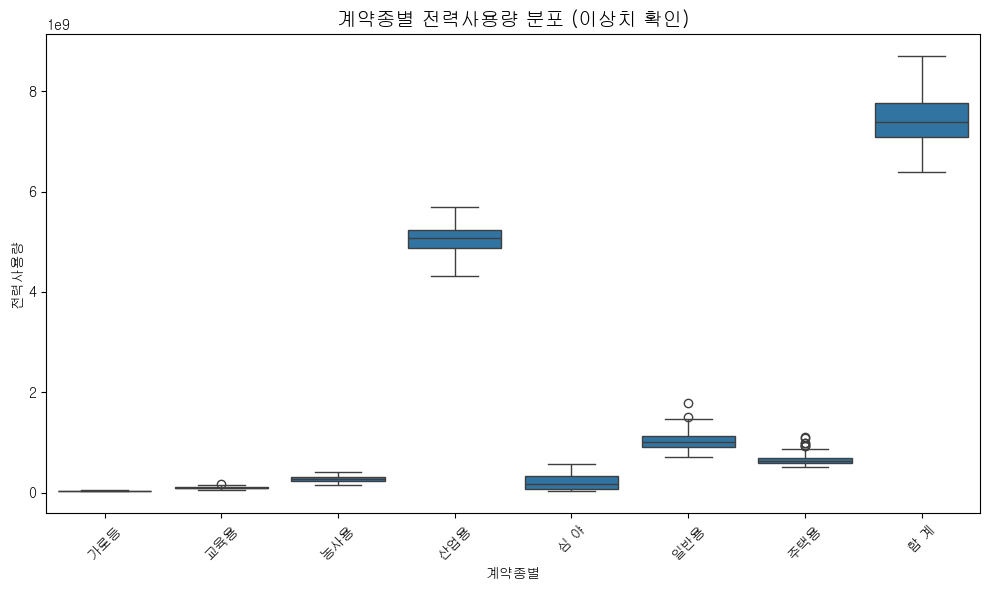

In [394]:
# 이상치 확인
plt.figure(figsize=(10, 6))
sns.boxplot(data=power_monthly, x='계약종별', y='전력사용량')
plt.title('계약종별 전력사용량 분포 (이상치 확인)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('이상치 확인_png, dpi=300', bbox_inches='tight')
print("그래프 저장: 이상치_확인.png")
plt.show()


In [395]:
def get_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # 범위 밖 데이터만 필터링
    return df[(df[col] < lower) | (df[col] > upper)]



print('이상치 확인:')
for contract in ['주택용', '일반용', '산업용']:
    subset = df_final[df_final['계약종별'] == contract]
    outliers = get_outliers(subset, '전력사용량')
    print(f"[{contract}] 이상치: {len(outliers)}개")

    if len(outliers) > 0:
        print(outliers[['년월', '전력사용량']])


이상치 확인:
[주택용] 이상치: 7개
          년월       전력사용량
270  2018-08   933485928
558  2021-08   983538514
654  2022-08   956057383
750  2023-08   994995939
758  2023-09   924754651
846  2024-08  1096861563
854  2024-09  1109218719
[일반용] 이상치: 1개
          년월       전력사용량
589  2021-12  1790761875
[산업용] 이상치: 0개


In [396]:
# 데이터 통합 (merge 활용하여 데이터 통합 후 산점도 그래프 (scatter plot) 시각화하여 이상치 확인
df_final = pd.merge(power_monthly, weather_monthly, on='년월', how='inner')
print(f"\n통합 데이터: {df_final.shape}")
print(f"기간: {df_final['년월'].min()} ~ {df_final['년월'].max()}")
print(f"계약종별: {df_final['계약종별'].unique()}")
print("\n미리보기:")
print(df_final.head())


통합 데이터: (880, 9)
기간: 2015-11 ~ 2024-12
계약종별: <StringArray>
['가로등', '교육용', '농사용', '산업용', '심 야', '일반용', '주택용', '합 계']
Length: 8, dtype: str

미리보기:
        년월 계약종별       전력사용량  평균기온(°C)  평균현지기압(hPa)  평균상대습도(%)  평균풍속(m/s)  \
0  2015-11  가로등    40982916  9.311111  1012.255556  82.888889   1.377778   
1  2015-11  교육용    83778322  9.311111  1012.255556  82.888889   1.377778   
2  2015-11  농사용   322939086  9.311111  1012.255556  82.888889   1.377778   
3  2015-11  산업용  4742823646  9.311111  1012.255556  82.888889   1.377778   
4  2015-11  심 야   231499924  9.311111  1012.255556  82.888889   1.377778   

      일조율(%)  월합강수량(00~24h만)(mm)  
0  22.624444          126.044444  
1  22.624444          126.044444  
2  22.624444          126.044444  
3  22.624444          126.044444  
4  22.624444          126.044444  


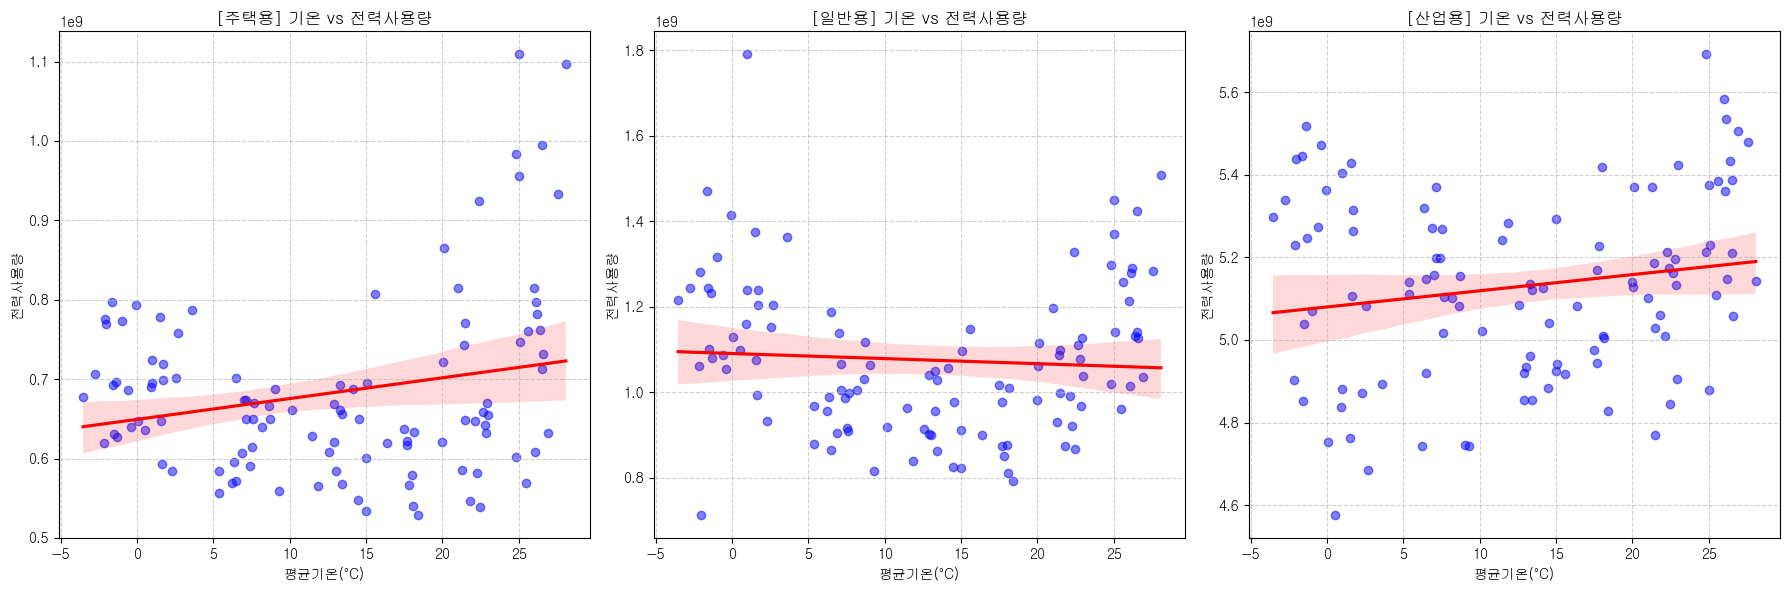

In [397]:
# 모델링 - 상관관계분석
target_contracts = ['주택용', '일반용', '산업용']

plt.figure(figsize=(18, 6))

for i, contracts in enumerate(target_contracts, 1):
    plt.subplot(1, 3, i)

    subset = df_final[df_final['계약종별'] == contracts]

    sns.regplot(data=subset, x='평균기온(°C)', y='전력사용량', 
                scatter_kws={'alpha':0.5, 'color':'blue'},  # 점 투명도와 색상
                line_kws={'color':'red'})                   # 회귀선 색상
    
    plt.title(f'[{contracts}] 기온 vs 전력사용량')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [398]:
weather_monthly = weather_cc.groupby(['년월']).agg({
    '평균기온(°C)': 'mean',           # 평균 기온
    '평균현지기압(hPa)': 'mean',       # 평균 기압
    '평균상대습도(%)': 'mean',         # 평균 습도
    '평균풍속(m/s)': 'mean',          # 평균 풍속
    '일조율(%)': 'mean',              # 일조율
    '월합강수량(00~24h만)(mm)': 'mean' # 강수량
}).reset_index()

In [399]:
#  상관관계 분석 
print("="*70)
print("계약종별 상관관계 분석")
print("="*70)

for contract in ['주택용', '일반용', '산업용']:
    print(f"\n[{contract}]")
    print("-"*50)
    
    subset = df_final[df_final['계약종별'] == contract]
    
    # 상관계수 계산
    corr_기온 = subset[['전력사용량', '평균기온(°C)']].corr().iloc[0, 1]
    corr_기압 = subset[['전력사용량', '평균현지기압(hPa)']].corr().iloc[0, 1]
    corr_습도 = subset[['전력사용량', '평균상대습도(%)']].corr().iloc[0, 1]
    corr_풍속 = subset[['전력사용량', '평균풍속(m/s)']].corr().iloc[0, 1]
    corr_일조율 = subset[['전력사용량', '일조율(%)']].corr().iloc[0, 1]
    corr_강수량 = subset[['전력사용량', '월합강수량(00~24h만)(mm)']].corr().iloc[0, 1]
    
    print(f"기온:    {corr_기온:6.3f}")
    print(f"기압:    {corr_기압:6.3f}")
    print(f"습도:    {corr_습도:6.3f}")
    print(f"풍속:    {corr_풍속:6.3f}")
    print(f"일조율:  {corr_일조율:6.3f}")
    print(f"강수량:  {corr_강수량:6.3f}")

    # 가장 강한 상관관계 찾기
    corrs = {
        '기온': abs(corr_기온),
        '기압': abs(corr_기압),
        '습도': abs(corr_습도),
        '풍속': abs(corr_풍속),
        '일조율': abs(corr_일조율),
        '강수량': abs(corr_강수량)
    }

    max_factor = max(corrs, key=corrs.get)
    print(f"\n→ 가장 강한 상관관계: {max_factor} ({corrs[max_factor]:.3f})")
   

계약종별 상관관계 분석

[주택용]
--------------------------------------------------
기온:     0.225
기압:    -0.180
습도:     0.342
풍속:    -0.229
일조율:  -0.220
강수량:   0.325

→ 가장 강한 상관관계: 습도 (0.342)

[일반용]
--------------------------------------------------
기온:    -0.064
기압:     0.038
습도:     0.182
풍속:    -0.131
일조율:  -0.145
강수량:   0.186

→ 가장 강한 상관관계: 강수량 (0.186)

[산업용]
--------------------------------------------------
기온:     0.170
기압:    -0.225
습도:     0.219
풍속:    -0.127
일조율:  -0.180
강수량:   0.294

→ 가장 강한 상관관계: 강수량 (0.294)


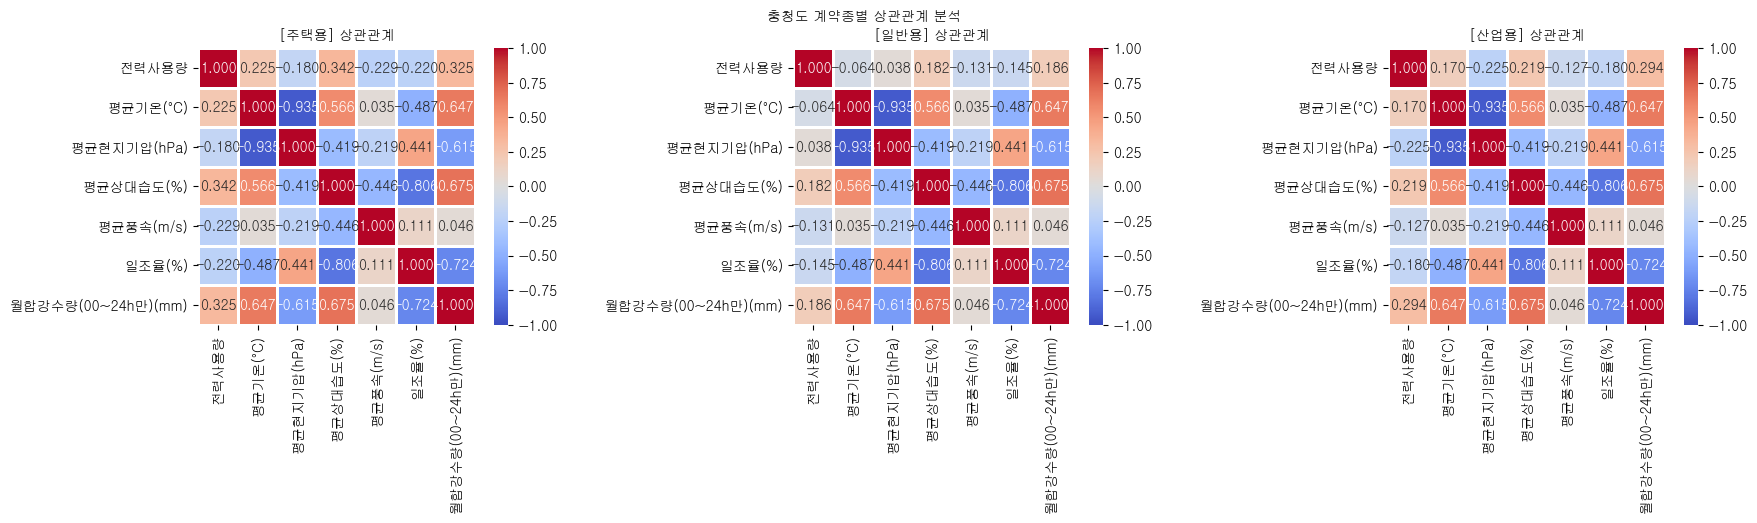

In [400]:
# ========== 상관관계 히트맵 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, contract in enumerate(['주택용', '일반용', '산업용']):
    subset = df_final[df_final['계약종별'] == contract]
    
    # 상관관계 행렬
    cols = ['전력사용량', '평균기온(°C)', '평균현지기압(hPa)', '평균상대습도(%)', '평균풍속(m/s)', '일조율(%)', '월합강수량(00~24h만)(mm)']
    corr_matrix = subset[cols].corr()
    
    # 히트맵
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', 
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                ax=axes[idx], square=True, linewidths=1)
    
    axes[idx].set_title(f'[{contract}] 상관관계', fontsize=10, fontweight='bold')

plt.suptitle('충청도 계약종별 상관관계 분석', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('충청도_상관관계_히트맵.png', dpi=300, bbox_inches='tight')
plt.show()

# 분석 인사이트

- 분석 대상: 충청권 (대전, 세종, 충남, 충북) 4개 시도 및 주요 기상 관측 지점 (서산, 천안, 청주, 제천 등) 데이터 통합

- 데이터 정제 : 기상청 및 한국전력 데이터를 '년월' 기준으로 병합
    - 결측치 처리: 적설량 등 특정 변수 0 처리 및 계절성을 고려한 월별 평균값 보강

주요 분석 결과:
- 1. 날씨의 영향은 예상보다 약하다
    - 대부분의 상관계수가 0.3 미만. 계절적 요인(여름/겨울) 이 더 중요
- 2. 강수량이 의외로 영향이 크다.
    - 모든 계약종별에서 양의 상관관계. 특히 주택용에서 0.337로 가장 높음
- 3. 계약종별로 뚜렷한 차이
    - 주택용: 날씨 영향 상대적으로 큼
    - 산업용: 날씨 영향 적음
    - 일반용: 증간 정도
- 4. 기온과의 관계 - 단순 상관관계는 약하게 나타났으며 실제로는 U자형 관계 
        (너무 춥거나 더울때 증가)
사용량에 가장 지배적인 영향을 미침. 습도나 강수량은 기온에 비해 전력 소비에 직접적인 영향을 주는 정도가 낮았음. 
   - 계약종별 차이: 기온 민감도는 일반용 > 주택용 > 산업용 순으로 나타남. 산업계보다는 상업 닟 주거지역의 냉난방 부하 조절이 더 효율적임을 시사함. 
   - 향후 연구 방향: 기온 외 불쾌지수 변수를 새로 생성하여 분석한다면 단순 기온보다 더 정확한 전력 수요 예측 모델을 만들 수 있을 것으로 예측되며, 또한 겨울철 난방 수요를 분리하여 분석하기 위해 데이터를 동/하절기로 나누어 비교하는 추가 연구가 이어진다면 좋을 것으로 보여짐. 

->> 일반용 전력이 주택용보다 기온에 더 민감하다. 

날씨가 전력에 미치는 영향: 기상 변수 중 평균 기온이 압도적으로 큰 영향을 미치며, 그 뒤로 습도와 일조율이 미세한 영향을 준다. 풍속이나 강수량은 전력 사용량과 직접적인 연관성이 거의 발견되지 아니함. 

계약종별 차이: 일반용 > 주택용 > 산업용 순 (기온민감도)

* 2018년 8월과 2024년 8월에 전력 사용량이 역대급으로 높게 나타났는데 이는 당시 발생했던 기록적인 폭염기록과 일치함. 기상이변이 전력계통에 주는 충격이 일반용 전력에서 가장 먼저 나타난다는 점을 유추할 수 있다. 

In [402]:
df_final.to_csv('충청도_최종분석데이터.csv', index=False, encoding='utf-8-sig')
print("데이터 저장 : 충청도_최종분석데이터.csv")

데이터 저장 : 충청도_최종분석데이터.csv
